### 1. Import Libraries

In [22]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from pathlib import Path

### 2. Load the dataset

In [ ]:
# Load the dataset
df = pd.read_csv("/home/surendran-g/Documents/AI_Job_Recommendation_System/dataset/Resume.csv")
print(df.shape)

(2484, 4)


### 3. Basic Checks

In [7]:
print(df.head())

         ID                                         Resume_str  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2  33176873           HR DIRECTOR       Summary      Over 2...   
3  27018550           HR SPECIALIST       Summary    Dedica...   
4  17812897           HR MANAGER         Skill Highlights  ...   

                                         Resume_html Category  
0  <div class="fontsize fontface vmargins hmargin...       HR  
1  <div class="fontsize fontface vmargins hmargin...       HR  
2  <div class="fontsize fontface vmargins hmargin...       HR  
3  <div class="fontsize fontface vmargins hmargin...       HR  
4  <div class="fontsize fontface vmargins hmargin...       HR  


In [8]:
print(df.dtypes)

ID             int64
Resume_str       str
Resume_html      str
Category         str
dtype: object


In [9]:
print(df['Category'].value_counts())

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [11]:
#Load PDFs from category folders
import glob

pdf_files = glob.glob("/home/surendran-g/Documents/AI_Job_Recommendation_System/dataset/data/ACCOUNTANT/78403342.pdf", recursive=True)

# Build a dataframe from file paths
records = []
for path in pdf_files:
    category = os.path.basename(os.path.dirname(path))
    filename = os.path.basename(path)
    size_kb = os.path.getsize(path) / 1024
    records.append({"category": category, "filename": filename, "size_kb": round(size_kb, 2), "path": path})

pdf_df = pd.DataFrame(records)
print(pdf_df.shape)
print(pdf_df.head())
print(pdf_df['category'].value_counts())

(1, 4)
     category      filename  size_kb  \
0  ACCOUNTANT  78403342.pdf    24.26   

                                                path  
0  /home/surendran-g/Documents/AI_Job_Recommendat...  
category
ACCOUNTANT    1
Name: count, dtype: int64


### 4. Quqlity Checks

In [12]:
# Shape 
print("Shape (rows × cols):", df.shape)
print(f"  → {df.shape[0]:,} resumes, {df.shape[1]} columns\n")

# Column data types
print("Data types:")
print(df.dtypes)
print()

# Memory usage
print("Memory usage per column:")
print(df.memory_usage(deep=True).apply(lambda x: f"{x/1024:.1f} KB"))
print(f"\nTotal memory: {df.memory_usage(deep=True).sum()/1024:.1f} KB")
print()

# Quick peek 
print("First 2 rows:")
df.head(2)

Shape (rows × cols): (2484, 4)
  → 2,484 resumes, 4 columns

Data types:
ID             int64
Resume_str       str
Resume_html      str
Category         str
dtype: object

Memory usage per column:
Index              0.1 KB
ID                19.4 KB
Resume_str     25229.5 KB
Resume_html    62699.7 KB
Category         141.9 KB
dtype: str

Total memory: 88090.5 KB

First 2 rows:


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR


In [13]:
# Missing values
# Null counts per column
null_counts = df.isnull().sum()
null_pct   = (null_counts / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "null_count" : null_counts,
    "null_pct"   : null_pct,
    "dtype"      : df.dtypes
})
print("Missing value summary:")
print(missing_df.to_string())
print()

# Empty string check (whitespace-only counts as missing too)
print("Empty / whitespace-only strings:")
for col in ["Resume_str", "Resume_html", "Category"]:
    empty = (df[col].astype(str).str.strip() == "").sum()
    print(f"  {col:<16}: {empty}")
print()

# Rows with ANY null 
rows_with_null = df.isnull().any(axis=1).sum()
print(f"Rows with at least one null: {rows_with_null}")

# Category coverage
print(f"\nDistinct categories: {df['Category'].nunique()}")
print("Category null check:", df['Category'].isnull().sum())

Missing value summary:
             null_count  null_pct  dtype
ID                    0       0.0  int64
Resume_str            0       0.0    str
Resume_html           0       0.0    str
Category              0       0.0    str

Empty / whitespace-only strings:
  Resume_str      : 1
  Resume_html     : 0
  Category        : 0

Rows with at least one null: 0

Distinct categories: 24
Category null check: 0


In [14]:
# Duplication Check
# Duplicate IDs
dup_ids = df[df.duplicated(subset="ID", keep=False)]
print(f"Duplicate IDs   : {df.duplicated(subset='ID').sum()}")
if not dup_ids.empty:
    print("Rows with duplicate IDs:")
    print(dup_ids[["ID", "Category"]])

# Duplicate Resume_str
dup_text = df.duplicated(subset="Resume_str").sum()
print(f"Duplicate Resume_str: {dup_text}")
print()

# Full-row duplicates 
dup_full = df.duplicated().sum()
print(f"Full-row duplicates  : {dup_full}")
print()

# Show any duplicate Resume_str pairs 
if dup_text > 0:
    dup_rows = df[df.duplicated(subset="Resume_str", keep=False)]
    print("Rows with duplicate Resume_str:")
    print(dup_rows[["ID", "Category"]].sort_values("Category").to_string())
else:
    print("All Resume_str entries are unique.")

Duplicate IDs   : 0
Duplicate Resume_str: 2

Full-row duplicates  : 0

Rows with duplicate Resume_str:
            ID  Category
2444  16850314  AVIATION
2483  37473139  AVIATION
1490  19147603   FINANCE
1509  28398216   FINANCE


In [ ]:
# Quality check summary
# Consolidated EDA summary 
summary = {
    "Total resumes"         : df.shape[0],
    "Total columns"         : df.shape[1],
    "Missing values"        : df.isnull().sum().sum(),
    "Duplicate IDs"         : df.duplicated(subset="ID").sum(),
    "Duplicate Resume_str"  : df.duplicated(subset="Resume_str").sum(),
    "Full-row duplicates"   : df.duplicated().sum(),
    "Unique categories"     : df["Category"].nunique(),
    "Dataset clean?"        : all([
        df.isnull().sum().sum() == 0,
        df.duplicated(subset="ID").sum() == 0,
        df.duplicated(subset="Resume_str").sum() == 0
    ])
}
print("EDA Summary")
for k, v in summary.items():
    flag = "" if v == 0 or v is True else ("" if v is False else "")
    print(f"  {k:<26}: {v}  {flag}")

EDA Summary
  Total resumes             : 2484  
  Total columns             : 4  
  Missing values            : 0  
  Duplicate IDs             : 0  
  Duplicate Resume_str      : 2  
  Full-row duplicates       : 0  
  Unique categories         : 24  
  Dataset clean?            : False  


### 5. Target Variable Analysis 

In [17]:
# ── Class frequency count ──────────────────────────────────────────
class_counts = (
    df["Category"]
    .value_counts()
    .reset_index()
    .rename(columns={"Category": "category", "count": "count"})
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

# Add percentage column
class_counts["pct"] = (class_counts["count"] / class_counts["count"].sum() * 100).round(2)

print(f"Total categories : {len(class_counts)}")
print(f"Max count        : {class_counts['count'].max()}  ({class_counts.iloc[0]['category']})")
print(f"Min count        : {class_counts['count'].min()}  ({class_counts.iloc[-1]['category']})")
print(f"Imbalance ratio  : {class_counts['count'].max() / class_counts['count'].min():.2f}x")
print()
print(class_counts.to_string(index=False))

Total categories : 24
Max count        : 120  (INFORMATION-TECHNOLOGY)
Min count        : 22  (BPO)
Imbalance ratio  : 5.45x

              category  count  pct
INFORMATION-TECHNOLOGY    120 4.83
  BUSINESS-DEVELOPMENT    120 4.83
              ADVOCATE    118 4.75
                  CHEF    118 4.75
               FINANCE    118 4.75
           ENGINEERING    118 4.75
            ACCOUNTANT    118 4.75
               FITNESS    117 4.71
              AVIATION    117 4.71
                 SALES    116 4.67
            HEALTHCARE    115 4.63
            CONSULTANT    115 4.63
               BANKING    115 4.63
          CONSTRUCTION    112 4.51
      PUBLIC-RELATIONS    111 4.47
                    HR    110 4.43
              DESIGNER    107 4.31
                  ARTS    103 4.15
               TEACHER    102 4.11
               APPAREL     97 3.90
         DIGITAL-MEDIA     96 3.86
           AGRICULTURE     63 2.54
            AUTOMOBILE     36 1.45
                   BPO     22 0.89

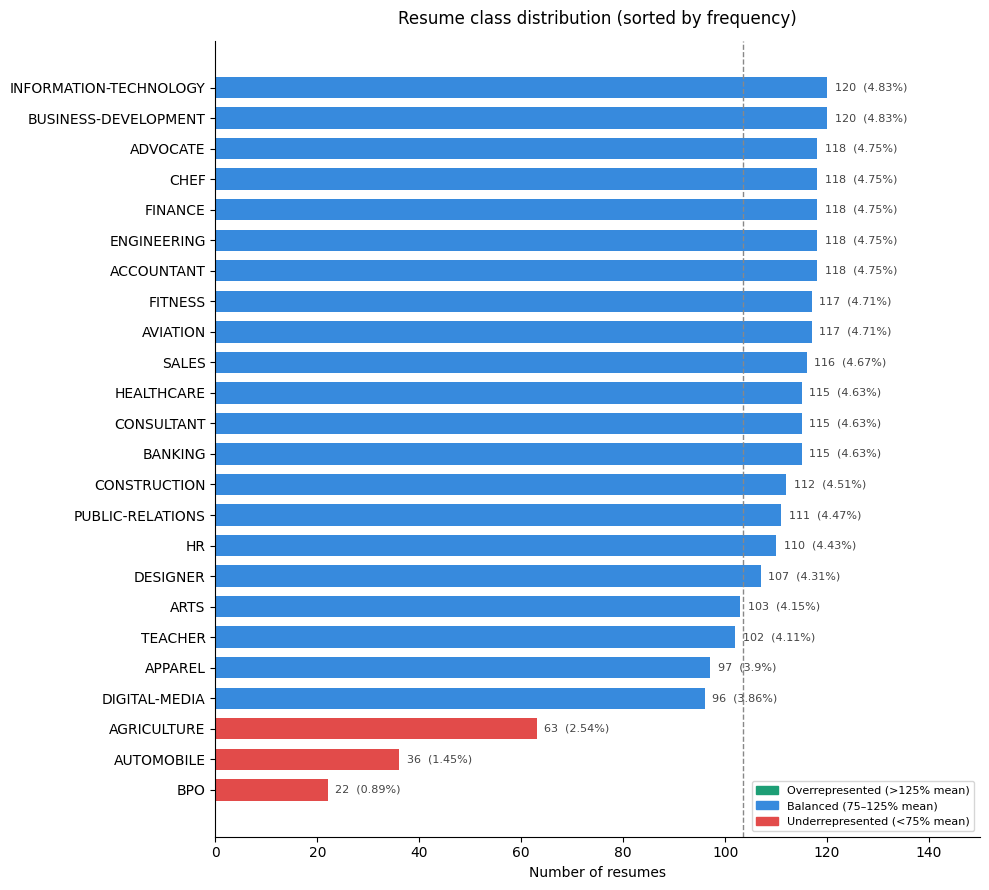

In [ ]:
# Colour-code bars by imbalance severity 
mean_count = class_counts["count"].mean()
threshold_low  = mean_count * 0.75   # < 75 % of mean → underrepresented
threshold_high = mean_count * 1.25   # > 125 % of mean → overrepresented

def get_color(count):
    if count < threshold_low:   return "#E24B4A"   # red  – underrepresented
    if count > threshold_high:  return "#1D9E75"   # teal – overrepresented
    return "#378ADD"                               # blue – balanced

colors = [get_color(c) for c in class_counts["count"]]

# Plot 
fig, ax = plt.subplots(figsize=(10, 9))

bars = ax.barh(
    class_counts["category"],
    class_counts["count"],
    color=colors, edgecolor="none", height=0.7
)

# Invert y-axis so highest is on top
ax.invert_yaxis()

# Count labels at end of each bar
for bar, count, pct in zip(bars, class_counts["count"], class_counts["pct"]):
    ax.text(
        bar.get_width() + 1.5, bar.get_y() + bar.get_height() / 2,
        f"{count}  ({pct}%)", va="center", fontsize=8, color="#444"
    )

# Mean reference line
ax.axvline(mean_count, color="#888", linestyle="--", linewidth=1,
           label=f"Mean = {mean_count:.0f}")

# Legend
legend_patches = [
    mpatches.Patch(color="#1D9E75", label="Overrepresented (>125% mean)"),
    mpatches.Patch(color="#378ADD", label="Balanced (75–125% mean)"),
    mpatches.Patch(color="#E24B4A", label="Underrepresented (<75% mean)"),
]
ax.legend(handles=legend_patches, fontsize=8, loc="lower right")

ax.set_xlabel("Number of resumes", fontsize=10)
ax.set_title("Resume class distribution (sorted by frequency)", fontsize=12, pad=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, class_counts["count"].max() + 30)

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
# Flag each category's imbalance status 
mean_count = class_counts["count"].mean()

def imbalance_flag(count):
    if count < mean_count * 0.75: return " underrepresented"
    if count > mean_count * 1.25: return " overrepresented"
    return " balanced"

class_counts["status"] = class_counts["count"].apply(imbalance_flag)

print(f"Mean per class : {mean_count:.1f}\n")
print(class_counts[["category", "count", "pct", "status"]].to_string(index=False))

print("\nStatus summary:")
print(class_counts["status"].value_counts().to_string())

Mean per class : 103.5

              category  count  pct            status
INFORMATION-TECHNOLOGY    120 4.83          balanced
  BUSINESS-DEVELOPMENT    120 4.83          balanced
              ADVOCATE    118 4.75          balanced
                  CHEF    118 4.75          balanced
               FINANCE    118 4.75          balanced
           ENGINEERING    118 4.75          balanced
            ACCOUNTANT    118 4.75          balanced
               FITNESS    117 4.71          balanced
              AVIATION    117 4.71          balanced
                 SALES    116 4.67          balanced
            HEALTHCARE    115 4.63          balanced
            CONSULTANT    115 4.63          balanced
               BANKING    115 4.63          balanced
          CONSTRUCTION    112 4.51          balanced
      PUBLIC-RELATIONS    111 4.47          balanced
                    HR    110 4.43          balanced
              DESIGNER    107 4.31          balanced
                  ARTS

### 6. Directory Cross-Validation